# Loan Approval Prediction 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  accuracy_score, confusion_matrix, classification_report, roc_auc_score,roc_curve

import warnings
warnings.filterwarnings('ignore')

In [2]:

train = pd.read_csv("Loan Prediction.csv")
print("Train shape:", train.shape)


Train shape: (614, 13)


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


### Loan Status Distribution


Loan Status Distribution:
 Loan_Status
Y    422
N    192
Name: count, dtype: int64


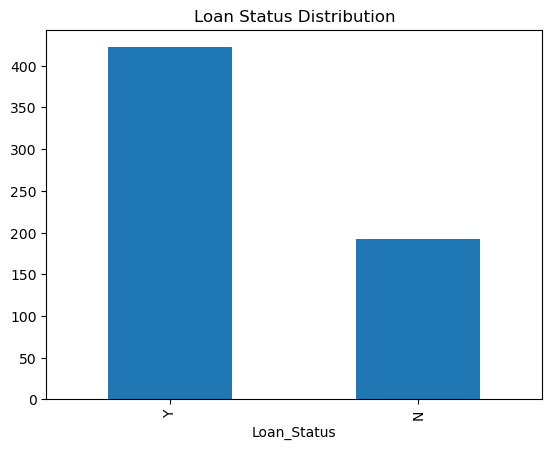

In [4]:

print("\nLoan Status Distribution:\n", train['Loan_Status'].value_counts())

train['Loan_Status'].value_counts().plot.bar(title='Loan Status Distribution')

plt.show()


#### Categorical Features

In [5]:

train['Married'].value_counts(normalize=True)


Married
Yes    0.651391
No     0.348609
Name: proportion, dtype: float64

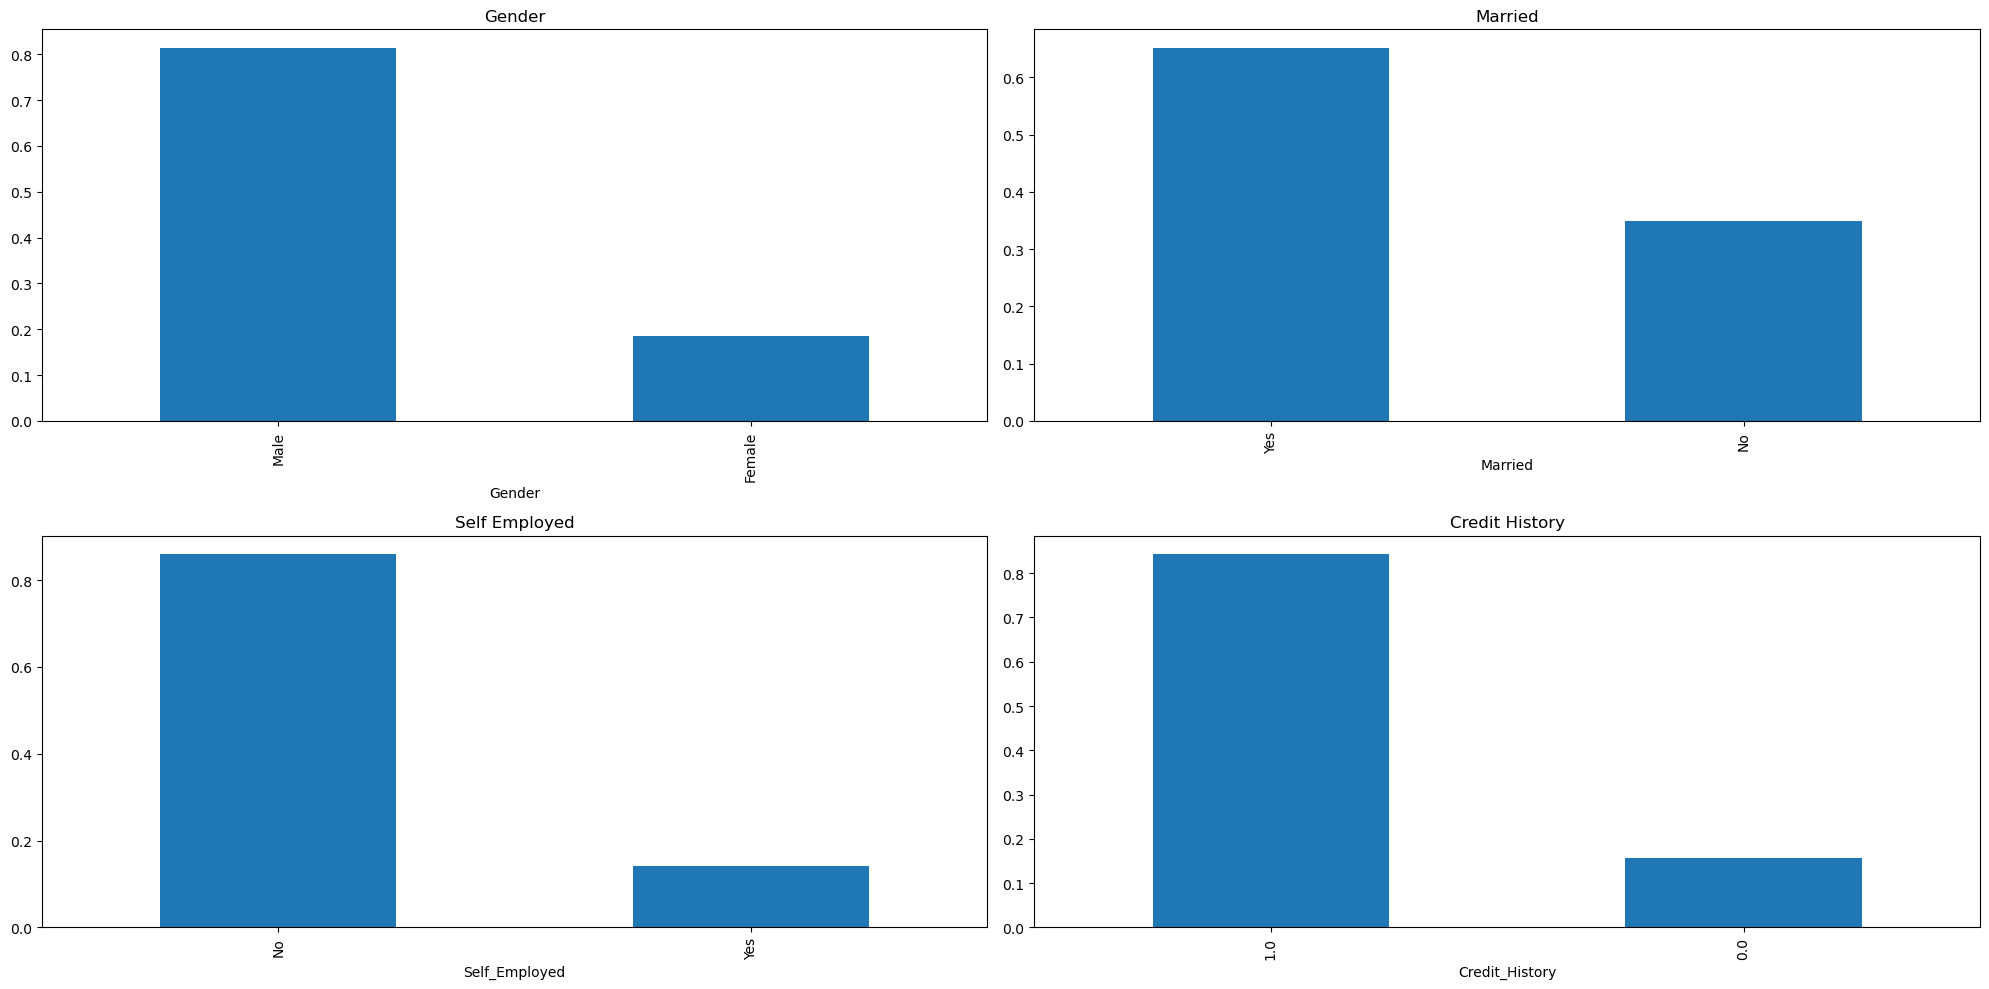

In [6]:

plt.figure(figsize=(20, 10))

plt.subplot(221); train['Gender'].value_counts(normalize=True).plot.bar(title='Gender')
plt.subplot(222); train['Married'].value_counts(normalize=True).plot.bar(title='Married')
plt.subplot(223); train['Self_Employed'].value_counts(normalize=True).plot.bar(title='Self Employed')
plt.subplot(224); train['Credit_History'].value_counts(normalize=True).plot.bar(title='Credit History')

plt.tight_layout()
plt.show()


#### Ordinal Features

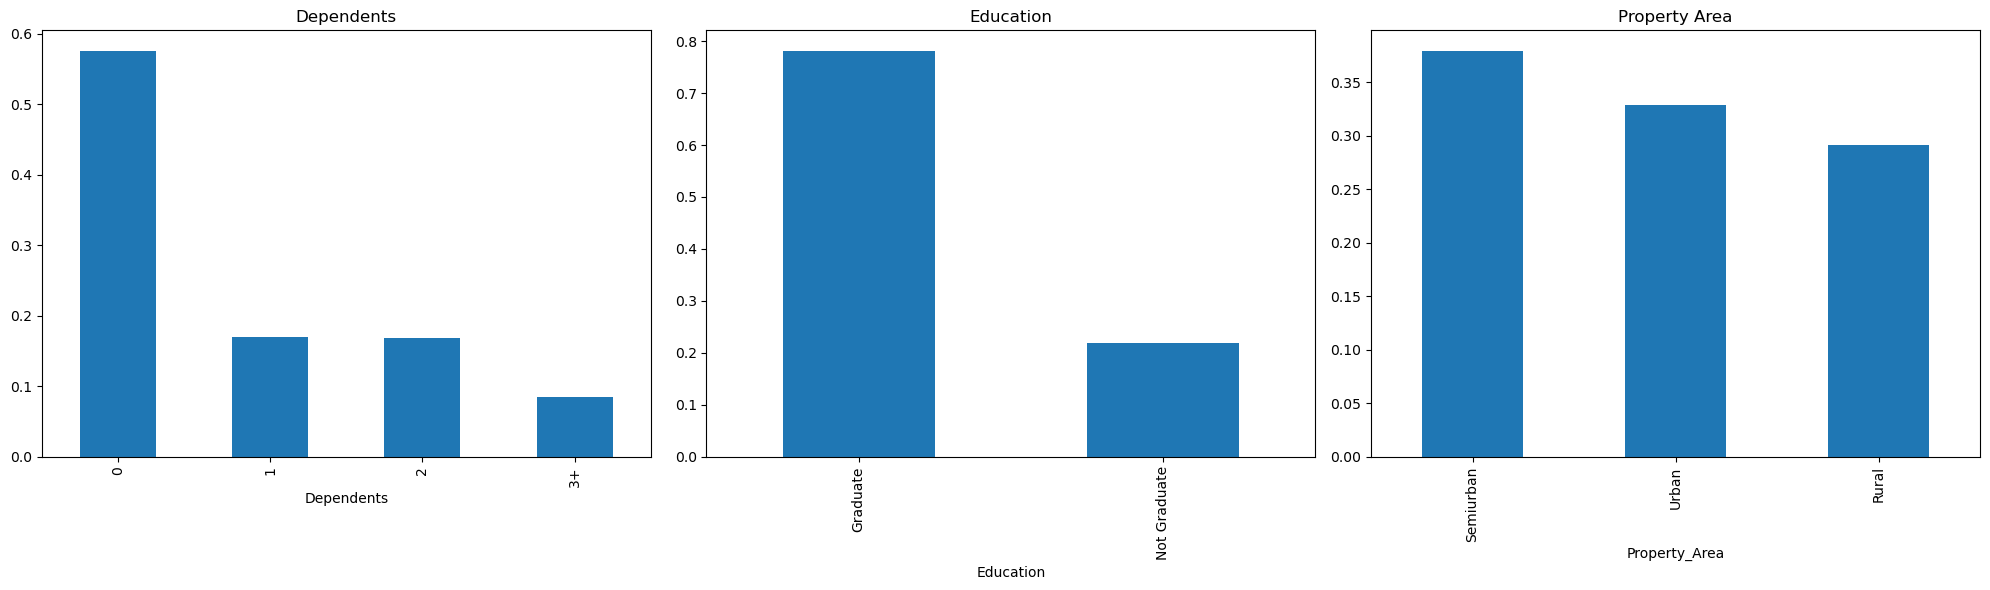

In [7]:
plt.figure(figsize=(20, 6))

plt.subplot(131); train['Dependents'].value_counts(normalize=True).plot.bar(title='Dependents')
plt.subplot(132); train['Education'].value_counts(normalize=True).plot.bar(title='Education')
plt.subplot(133); train['Property_Area'].value_counts(normalize=True).plot.bar(title='Property Area')

plt.tight_layout()
plt.show()


### Numerical Features

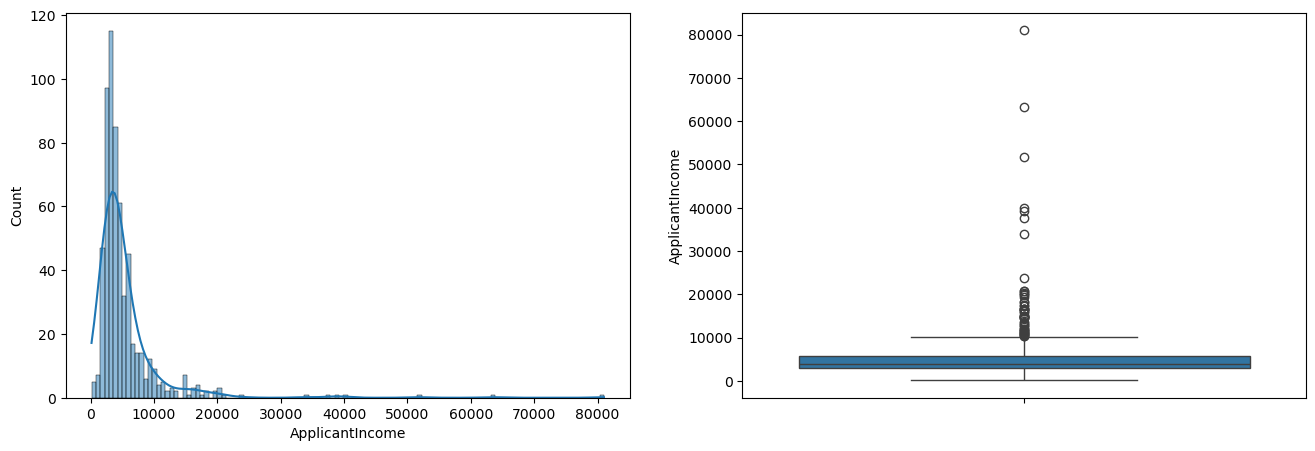

In [8]:

plt.figure(figsize=(16, 5))

plt.subplot(121); sns.histplot(train['ApplicantIncome'], kde=True)
plt.subplot(122); sns.boxplot(y=train['ApplicantIncome'])

plt.show()


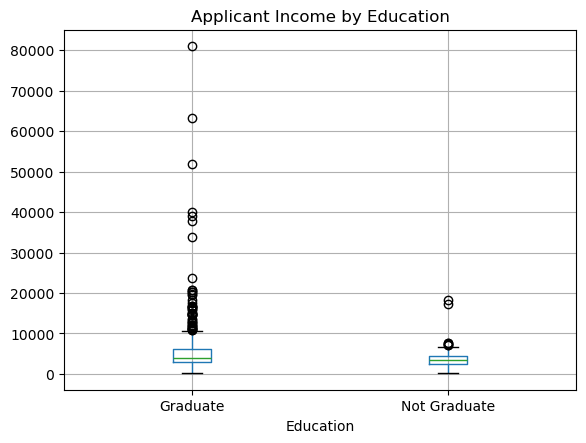

In [9]:

train.boxplot(column='ApplicantIncome', by='Education')

plt.title("Applicant Income by Education")
plt.suptitle("")
plt.show()

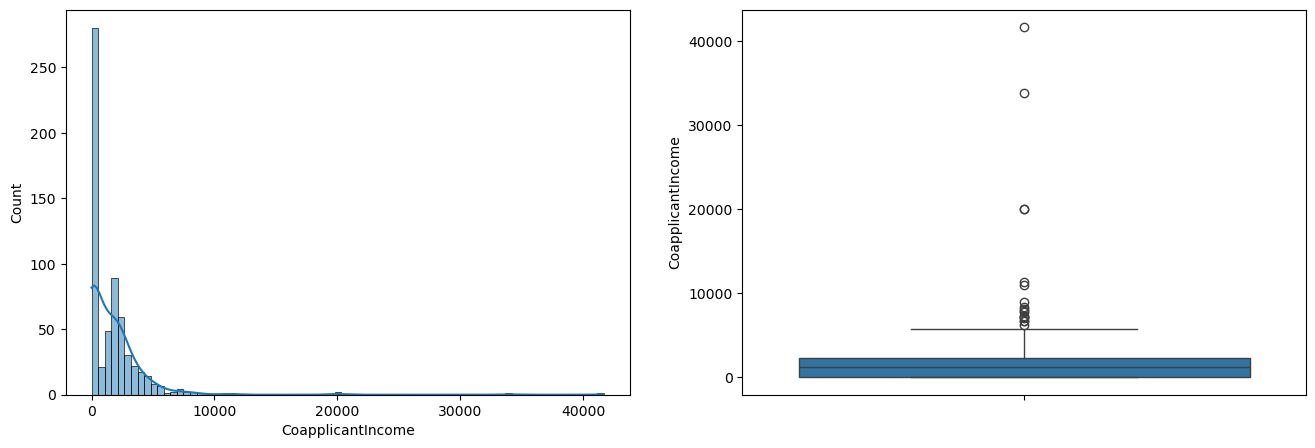

In [10]:
plt.figure(figsize=(16, 5))

plt.subplot(121); sns.histplot(train['CoapplicantIncome'], kde=True)
plt.subplot(122); sns.boxplot(y=train['CoapplicantIncome'])

plt.show()

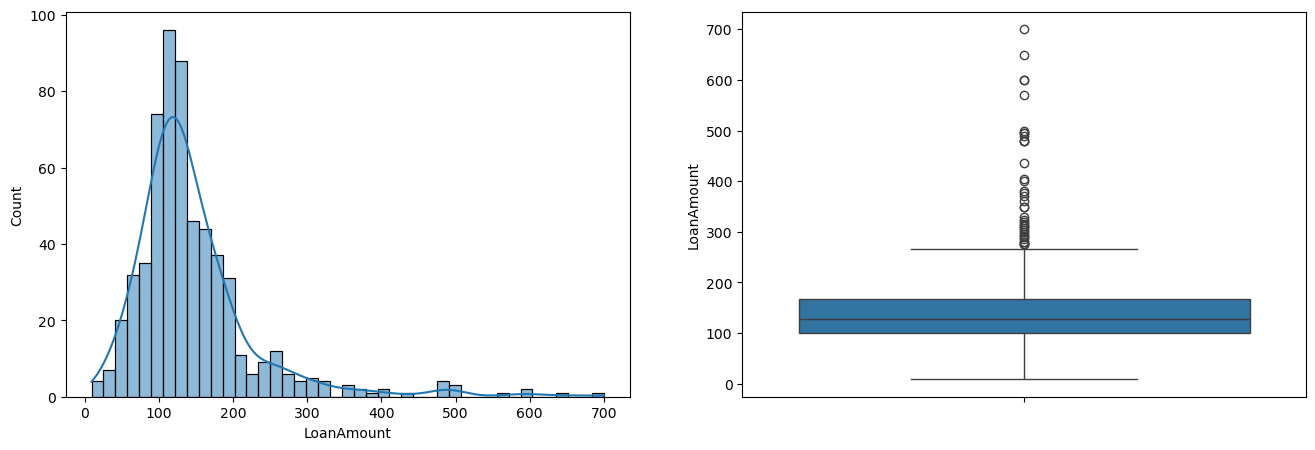

In [11]:
plt.figure(figsize=(16, 5))

plt.subplot(121); sns.histplot(train['LoanAmount'].dropna(), kde=True)
plt.subplot(122); sns.boxplot(y=train['LoanAmount'])

plt.show()

# Missing Values

In [12]:

print("\nMissing values before handling:\n", train.isnull().sum())



Missing values before handling:
 Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


In [13]:
# Fill missing values
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    train[col] = train[col].fillna(train[col].mode()[0])


In [14]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [15]:

train['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [16]:

train['Loan_Amount_Term'] = train['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
train['LoanAmount'] = train['LoanAmount'].fillna(train['LoanAmount'].median())


In [17]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


### Feature Engineering

In [18]:

train['LoanAmount_log'] = np.log1p(train['LoanAmount'])  


In [19]:

train.drop(['Loan_ID'], axis=1, inplace=True)


In [20]:

train['Loan_Status'] = train['Loan_Status'].map({'Y': 1, 'N': 0})


In [21]:

train


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LoanAmount_log
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1,4.859812
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0,4.859812
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1,4.204693
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1,4.795791
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1,4.955827
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,1,4.276666
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,1,3.713572
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,1,5.537334
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,1,5.236442


### Encoding

In [22]:

X = train.drop('Loan_Status', axis=1)
y = train['Loan_Status']


In [23]:

X = pd.get_dummies(X)


In [24]:
X

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,LoanAmount_log,Gender_Female,Gender_Male,Married_No,Married_Yes,...,Dependents_1,Dependents_2,Dependents_3+,Education_Graduate,Education_Not Graduate,Self_Employed_No,Self_Employed_Yes,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,4.859812,False,True,True,False,...,False,False,False,True,False,True,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,4.859812,False,True,False,True,...,True,False,False,True,False,True,False,True,False,False
2,3000,0.0,66.0,360.0,1.0,4.204693,False,True,False,True,...,False,False,False,True,False,False,True,False,False,True
3,2583,2358.0,120.0,360.0,1.0,4.795791,False,True,False,True,...,False,False,False,False,True,True,False,False,False,True
4,6000,0.0,141.0,360.0,1.0,4.955827,False,True,True,False,...,False,False,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,2900,0.0,71.0,360.0,1.0,4.276666,True,False,True,False,...,False,False,False,True,False,True,False,True,False,False
610,4106,0.0,40.0,180.0,1.0,3.713572,False,True,False,True,...,False,False,True,True,False,True,False,True,False,False
611,8072,240.0,253.0,360.0,1.0,5.537334,False,True,False,True,...,True,False,False,True,False,True,False,False,False,True
612,7583,0.0,187.0,360.0,1.0,5.236442,False,True,False,True,...,False,True,False,True,False,True,False,False,False,True


In [25]:
# Train-Test Split
x_train, x_cv, y_train, y_cv = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)


In [26]:
# Train Model
model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)


LogisticRegression(random_state=42)

#### Evaluation

In [27]:

pred_cv = model.predict(x_cv)

print("Validation Accuracy:", accuracy_score(y_cv, pred_cv))
print("\nConfusion Matrix:\n", confusion_matrix(y_cv, pred_cv))
print("\nClassification Report:\n", classification_report(y_cv, pred_cv))


Validation Accuracy: 0.8216216216216217

Confusion Matrix:
 [[ 32  26]
 [  7 120]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.55      0.66        58
           1       0.82      0.94      0.88       127

    accuracy                           0.82       185
   macro avg       0.82      0.75      0.77       185
weighted avg       0.82      0.82      0.81       185



ROC AUC Score: 0.8259571001900625


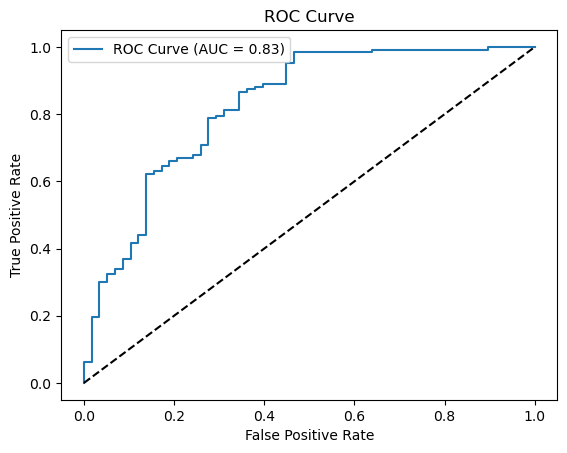

In [28]:
# ROC AUC Score

probs = model.predict_proba(x_cv)[:, 1]
roc_auc = roc_auc_score(y_cv, probs)
print("ROC AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_cv, probs)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [29]:
# Save Model & Columns
#joblib.dump(model, 'loan_model.pkl')

joblib.dump(X.columns.tolist(), 'model_columns.pkl')

['model_columns.pkl']

In [30]:

# Predict New Applicant
new_data_dict = {
    'Gender': ['Male'],
    'Married': ['Yes'],
    'Dependents': ['0'],
    'Education': ['Graduate'],
    'Self_Employed': ['No'],
    'ApplicantIncome': [5000],
    'CoapplicantIncome': [2000],
    'LoanAmount': [150],
    'Loan_Amount_Term': [360.0],
    'Credit_History': [1.0],
    'Property_Area': ['Urban']
}
new_data = pd.DataFrame(new_data_dict)
new_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,Yes,0,Graduate,No,5000,2000,150,360.0,1.0,Urban


In [31]:
# Preprocess new applicant
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']:
    new_data[col] = new_data[col].fillna(train[col].mode()[0])
    
new_data['Loan_Amount_Term'] = new_data['Loan_Amount_Term'].fillna(train['Loan_Amount_Term'].mode()[0])
new_data['LoanAmount'] = new_data['LoanAmount'].fillna(train['LoanAmount'].median())
new_data['LoanAmount_log'] = np.log1p(new_data['LoanAmount'])

In [32]:
# Encode new data
new_data_encoded = pd.get_dummies(new_data)
model_columns = joblib.load("model_columns.pkl")
new_data_encoded = new_data_encoded.reindex(columns=model_columns, fill_value=0)

In [33]:
# Predict
new_prediction = model.predict(new_data_encoded)
print("Prediction for new applicant:", "Loan Approved " if new_prediction[0] == 1 else "Loan Rejected ")


Prediction for new applicant: Loan Approved 
